ALGORITMI DI OTTIMIZZAZIONE (SGD, MOMENTUM, RMSPROP, ADAM)

I Gradienti ci dicon in che direzione andare
Il Learning Rate (eta) con che passo
La direzione cambia continuamente e il terrono è insidioso
Dobbiamo dare ai nostri algoritmi una memoria e una capacità di adattamento.
Trasformando la camminata incerta in una discesa fluida verso il minimo dell'errore.

* Momentum che introduce il concetto di inerzia  e RMSProp che impara a modulare la velocità la velocità.
* Adam: diventato la standard del Deep Learning (come punto di partenza), re degli ottimizzatori
* Analisi della velocità di convergenza tra Stochastic Gradient e Adam

OTTIMIZZAZIONE CON MEMORIA

Il Gradient Descent classico soffre di oscillazioni.
Il Momentum introduce una memoria dei passi precedenti.
Immagina una vallata stretta a lunga, la persona che la percorre ogni passo nota che le pareti sono ripide e continua a rimbalzare da un lato all'altro facendo pochi progressi verso il fondo della valle.
Il Momentum risolve questo problema, introduce una memoria dei passi precedenti.
Dall'altra parte l'RMSProp si occupa della scala, non tutti i pesi hanno bisogno di cambiare alla stessa velocità alcuni hanno bisogno di piccoli ritocchi, altri di grandi scossoni. 
La regola del tasso di apprendimento per ogni singolo parametro, evita che pesi con gradienti enormi destabilizzano l'intero sistema.

Il Momentum accumula velocità, se un gradiente punta costantemente nella stessa direzione, l'algoritmo accellera. Se invece inizia ad oscillare, la oscillazioni si cancellano a vicenda stabilizzando il percorso. Il Momentum non usa solo il gradiente attuale, ma una media pesata dei gradienti passati

RMSProp invece, guarda quanto sono stati grandi i gradienti recenti, divide il gradiente per una media mobile della sua grandezza recente. Questa normalizzazione garantisce che ogni aggiornamento dei parametri abbia una magnitudo simile, indipendentemente dalla scala originale. Garantisce che ogni aggiornamento sia significativo ma mai distruttivo

L'aggiornamento del Momentum dipende dal parametro gamma (coefficiente di attrito, di solito impostato a 0.9) che controlla quanto della velcoità passata mantenere, quando velocità del passo precedente mantenere (solitamente il 90%). 
Invece di accumulare gradienti, prendiamo il 90% del gradiente passato ed aggiungiuamo una costante piccolissima per evitare la divisione per zero quando il gradiente scompare.

Pensiamo al Gradient Descente come ad un uomo che cammina con cautela, ogni passo si ferma, pensa, controlla, cambia direzione e lunghezza del passo, è preciso ma lentissimo. Il Momentum trasforma l'uomo in una palla di piombo pesante, una volta iniziata a rotolare, la sua massa gli permete di superare piccole asperità del terrno senza fermarsi puntando dritta al fondo della valle.
RMRProp agisce come frizione intelligente, se la strada è ripida frena, se la pendenza è minima accellera per non perdere tempo, getta sabbia sul terreno quando la dicesce è troppo veloce.

Se uniamo il Gradiente e RMSProp nasce ADAM

ADAM

ADAM è l'ottimizzatore più utilizzato oggi. La sua forza risiede nel combinare i vantaggi del Momentum (stima del primo momento) e di RMSProp (stima del secondo momento).
Ha memoria del circuito ma sa anche adattare la potenza del motore ad ogni singola curva, in tempo reale.
Presentato nel 2014 ha preso piedo risolvendo problemi prima difficili.

Adam domina perchè è robusto, molti ottimizzatori richiedono ora di tunning, Adam invece è molto più veloce, leggerissimo in termini di memoria.

Adam corregge il momentum 
- Stima due momenti: calcola comtemporaneamente la media mobile dei gradienti e dei loro quadrati, calcola la direzione e la scala
- Correzione bias: risolve il problema delle stime iniziali che tendono verso zero all'inizio dell'addestramento. spinge artificialmente le medie
- Efficienza computazionale: richiede poca memori e scala molto bene con dataset grandi
- Configurazione standard: i valori suggeriti dai creatori (0.9 e 0.999)  funzionano quasi sempre ottimamente.

Adam non è sempre perfetto in ogni situazione.
L'SGD classico (Stochastic Gradient Descend) con un tuning perfetto, può raggiungere una generalizzazione leggermente migliore su compiti di visione complessi.
Tuttavia, nel 95% delle applicazioni pratiche Adam rimane la scelta migliore.

Utilzzate Adam per prototipare velocemente e per il 95% dei progetti, se state cercando molta accuratezza conviene tornare a SGD


STOCHASTIC GRADIENT vs ADAM
Contronto SGD e Adam sullo stesso problema di classificazione.
Unica variabile è il modo con cui aggiornano i pesi.
I segnali da monitorare è la velocità iniziale (che scende sotto 0.5) e la stabilitàm, la sensibilità, chi raggiunge l'accurezza più alta nel minor tempo

SGD e Adam a confronto
(quello che cambia è come aggiornano i pesi)

[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]
 ...
 [ 1.72760808 -0.42882943]
 [-1.01448644  0.13522904]
 [ 0.77438101  0.63428493]]


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Inizio addestramento SGD...
Inizio addestramento Adam...


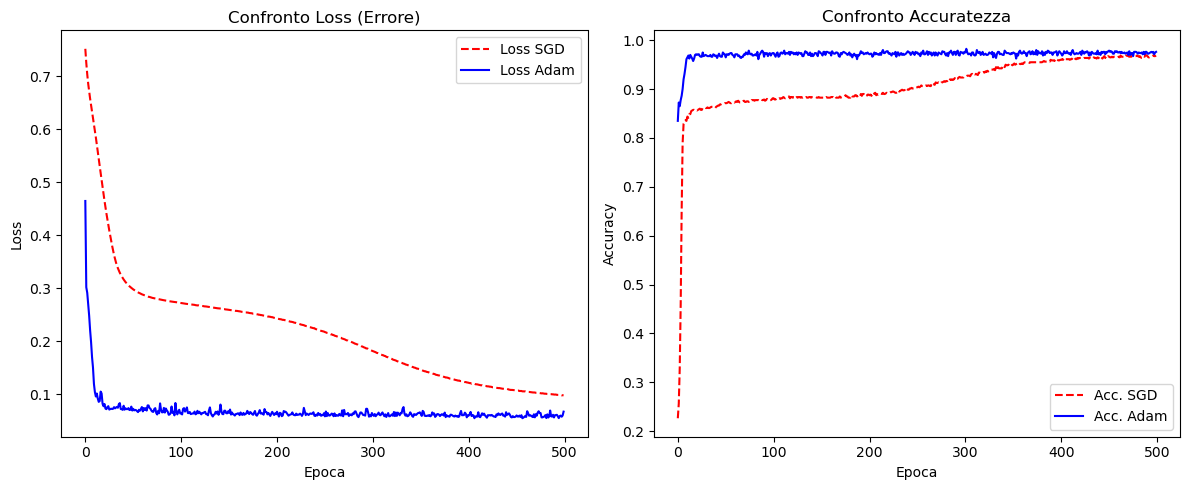

In [1]:
#chi scende sotto la loss di 0.5 per primo?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

# 1. Generazione di un dataset sintetico non lineare (due mezzelune)
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def build_model():
    """Crea una struttura di rete neurale fissa per il confronto."""
    model = Sequential([
        Dense(16, activation='relu', input_shape=(2,)), #layer1
        Dense(8, activation='relu'), #layer2
        Dense(1, activation='sigmoid') #layer3  uso sigmoide perchè è un problema di classificazione binaria e la sigmid restituisce o 0 o 1, quindi è perfetta per questo tipo di problema
    ])
    return model

# 2. Configurazione degli ottimizzatori
# Usiamo lo stesso Learning Rate iniziale per entrambi per un confronto equo
lr_iniziale = 0.01 #abbastanza standard

# MODELLO con SGD (Stochastic Gradient Descent classico)
model_sgd = build_model()
model_sgd.compile(optimizer=SGD(learning_rate=lr_iniziale), loss='binary_crossentropy', metrics=['accuracy'])

# MODELLO con ADAM (Ottimizzatore adattivo)
model_adam = build_model()
model_adam.compile(optimizer=Adam(learning_rate=lr_iniziale), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Addestramento
epochs = 50 #epoche di addestramento
print("Inizio addestramento SGD...")
history_sgd = model_sgd.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0, validation_data=(X_test, y_test))

print("Inizio addestramento Adam...")
history_adam = model_adam.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0, validation_data=(X_test, y_test))

# 4. Visualizzazione dei risultati
plt.figure(figsize=(12, 5))

# Plot della Loss
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['loss'], label='Loss SGD', color='red', linestyle='--')
plt.plot(history_adam.history['loss'], label='Loss Adam', color='blue')
plt.title('Confronto Loss (Errore)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

# Plot dell'Accuratezza
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['accuracy'], label='Acc. SGD', color='red', linestyle='--')
plt.plot(history_adam.history['accuracy'], label='Acc. Adam', color='blue')
plt.title('Confronto Accuratezza')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Epoche= 50 Adam parte in vantaggio sia nella Loss (più bassa è meglio è) sia nella Accuracy (più alta è meglio è).
Il modello riesce a migliorare velocemente con Adam molto più di di SGD che migliora lentamente (ha bisogno di più epoche per arrivare ai livelli di Adam)

Epoche=500 Adam parte in vantaggio sia per la Loss sia per la Accuray, e rimena vincitore anche alla fine in nettissimo in anticipo rispetto alle epoche di addestramento di SGD
SGD piano piano arriva anche lui al risultato

Epoche= 5000
Adam sempre migliore

A meno che si sta puntando alla efficienza assoluta non è detto che sempra conviene perchè i tempi potrebbero moltiplicarsi fino ad impiegare giorni e giorni.

Il numero di epoche sembra non influire sul migliorare le prestazioni di SGD rispetto a quelle di Adam, ma potrebbe anche essere 'colpa' del learning rate.
Il learning rate con Adam è ottimizzato molto più che con SGD, se lo cambio da 0.1 a 0.001 
Adam ci mette in filo di più a livello di epoche (rispetto a learning rate di 0.1) ma rimane sempre migliore rispetto a SGD. Mentre SGD non riesce a gestire un learning rate così basso con prestazioni inferiori rispetto al precedente learning rate

Adam ottine risultati migliori in tutte le situaizoni base
Adam agisce come un navigatore che ricalcola i percorsi ogni secondo. Se incontra una strata stretta, rallenta, se si trova in autostrada, accelera al massimo consentito.
Questa capacità di auto-calibrazione è ciò che ci permette di addestare modelli con milioni di parametri in tempi ragionevoli, senza dover intervenire manualmente a ogni step.